# Import Libraries

In [1]:
%pip install psycopg2 sqlalchemy
%pip install pandas as pd
%pip install numpy as np
%pip install matplotlib.pyplot as plt
%pip install seaborn as sns

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as


In [2]:
import pandas as pd
import numpy as np
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

In [3]:
load_dotenv()  # Load environment variables from .env file

connection = psycopg2.connect(
    host=os.environ.get("DB_HOST", "localhost"),
    database=os.environ.get("DB_NAME", "postgres"),
    user=os.environ.get("DB_USER", "postgres"),
    password=os.environ.get("DB_PASSWORD"),
    port=os.environ.get("DB_PORT", "5432"),
)


In [4]:
query = "SELECT * FROM text_messages"
df = pd.read_sql_query(query, connection)

df

C:\Users\Faiz Akhmad Daulay\AppData\Local\Temp\ipykernel_17948\152813437.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,date-received,date-read,sender,category,text
0,2025-12-12 14:35:50,2025-12-12 14:45:15,redacted_business,notifs,<REDACTED>
1,2025-12-12 15:05:04,2025-12-12 15:07:53,redacted_business,notifs,<REDACTED>
2,2025-12-12 15:55:09,2025-12-12 15:55:49,redacted_business,notifs,<REDACTED>
3,2025-12-12 18:39:19,2025-12-12 18:39:29,redacted_business,OTP,<REDACTED>
4,2025-12-12 18:42:20,2025-12-12 18:43:20,redacted_business,notifs,<REDACTED>
...,...,...,...,...,...
8250,2024-02-27 13:57:11,2024-02-27 14:02:26,eGovPH,gov,Pwede ng ma-access ang iba't ibang government ...
8251,2024-02-27 14:34:47,2024-02-27 14:38:44,eGovPH,gov,Pwede ng ma-access ang iba't ibang government ...
8252,2024-02-27 14:52:46,2024-02-27 15:08:42,eGovPH,gov,Pwede ng ma-access ang iba't ibang government ...
8253,2024-02-27 14:56:33,2024-02-27 15:08:42,eGovPH,gov,Pwede ng ma-access ang iba't ibang government ...


# Data Cleaning

In [5]:
df.isnull().sum()

date-received    0
date-read        0
sender           0
category         0
text             0
dtype: int64

In [6]:
df.duplicated().sum()

84

In [7]:
df = df.drop_duplicates()

In [8]:
df.duplicated().sum()

0

In [9]:
df['date-read'] = pd.to_datetime(df['date-read'], format='%Y-%m-%d %H:%M:%S')

C:\Users\Faiz Akhmad Daulay\AppData\Local\Temp\ipykernel_17948\1879912763.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date-read'] = pd.to_datetime(df['date-read'], format='%Y-%m-%d %H:%M:%S')


In [10]:
df['date-received'] = pd.to_datetime(df['date-received'], format='%Y-%m-%d %H:%M:%S')

C:\Users\Faiz Akhmad Daulay\AppData\Local\Temp\ipykernel_17948\4027887700.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date-received'] = pd.to_datetime(df['date-received'], format='%Y-%m-%d %H:%M:%S')


In [11]:
df.isnull().sum()

date-received    0
date-read        3
sender           0
category         0
text             0
dtype: int64

In [12]:
df = df.dropna()

In [13]:
df.isnull().sum()

date-received    0
date-read        0
sender           0
category         0
text             0
dtype: int64

# Explanatory Data Analysis

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8168 entries, 0 to 8254
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date-received  8168 non-null   datetime64[ns]
 1   date-read      8168 non-null   datetime64[ns]
 2   sender         8168 non-null   object        
 3   category       8168 non-null   object        
 4   text           8168 non-null   object        
dtypes: datetime64[ns](2), object(3)
memory usage: 382.9+ KB


In [15]:
df['category'].describe()

count       8168
unique         5
top       notifs
freq        5194
Name: category, dtype: object

In [16]:
df['category'].value_counts()

category
notifs    5194
ads       1057
OTP        948
spam       828
gov        141
Name: count, dtype: int64

<Axes: xlabel='category'>

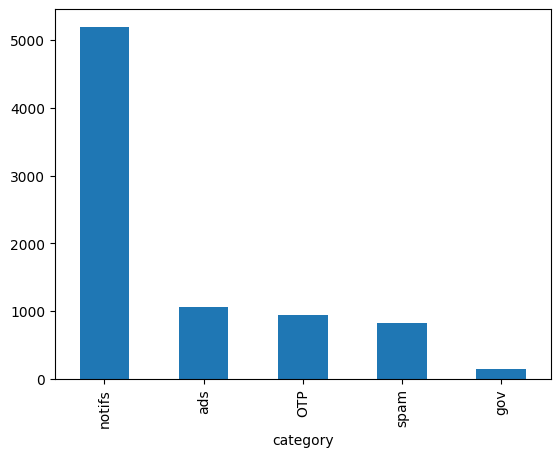

In [17]:
df['category'].value_counts().plot(kind='bar')

In [18]:
df['text_length'] = df['text'].apply(lambda x : len(str(x)))
df['word_count'] = df['text'].apply(lambda x : len(str(x).split()))

In [19]:
df.groupby('category')['text_length'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
OTP,948.0,10.00,0.00,10.0,10.0,10.0,10.0,10.0
ads,1057.0,214.86,134.98,6.0,139.0,160.0,305.0,722.0
gov,141.0,142.71,104.14,10.0,125.0,148.0,157.0,660.0
notifs,5194.0,10.08,3.47,10.0,10.0,10.0,10.0,157.0
spam,828.0,121.33,41.31,5.0,100.0,125.0,150.0,407.0


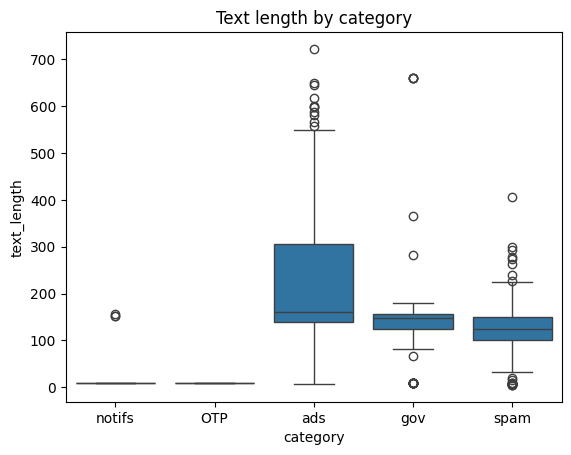

In [20]:
sns.boxplot(df, x='category', y='text_length')
plt.title("Text length by category")
plt.show()

In [21]:
df.groupby('category')['word_count'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
OTP,948.0,1.00,0.00,1.0,1.0,1.0,1.0,1.0
ads,1057.0,37.20,23.27,1.0,24.0,31.0,53.0,129.0
gov,141.0,23.29,18.02,1.0,21.0,24.0,24.0,113.0
notifs,5194.0,1.01,0.57,1.0,1.0,1.0,1.0,25.0
spam,828.0,18.76,6.87,1.0,15.0,19.0,23.0,68.0


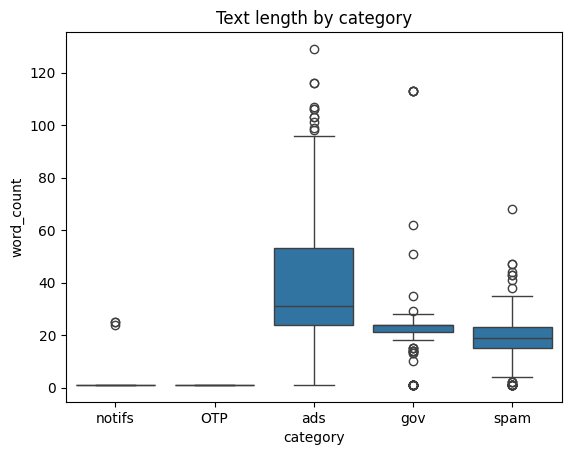

In [22]:
sns.boxplot(df, x='category', y='word_count')
plt.title("Text length by category")
plt.show()

In [23]:
df[df['text'] == '<REDACTED>'][['text', 'category']].value_counts()

text        category
<REDACTED>  notifs      5191
            OTP          948
            ads          125
            gov           19
            spam           1
Name: count, dtype: int64

In [24]:
total_rows = len(df)
redacted_count = (df['text'] == '<REDACTED>').sum()
redacted_percentage = (redacted_count / total_rows) * 100

print(f"\nTotal Redacted messages: {redacted_count} from {total_rows} ({redacted_percentage:.2f}%) data")


Total Redacted messages: 6284 from 8168 (76.93%) data


In [25]:
df['category'].value_counts()

category
notifs    5194
ads       1057
OTP        948
spam       828
gov        141
Name: count, dtype: int64

In [26]:
df = df[df['text'] != '<REDACTED>']

In [27]:
df['category'].value_counts()

category
ads       932
spam      827
gov       122
notifs      3
Name: count, dtype: int64

In [28]:
df = df[df['category'] != 'notifs']  # drop the leftover 3 rows

df['label'] = df['category'].apply(lambda x: 'spam' if x == 'spam' else 'not_spam')
df['label'].value_counts()

label
not_spam    1054
spam         827
Name: count, dtype: int64

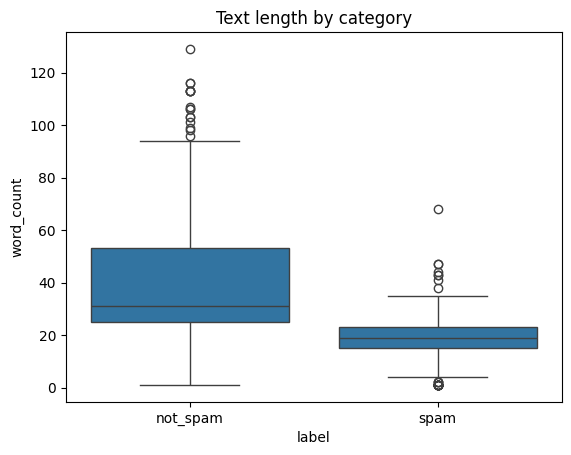

In [29]:
sns.boxplot(df, x='label', y='word_count')
plt.title("Text length by category")
plt.show()

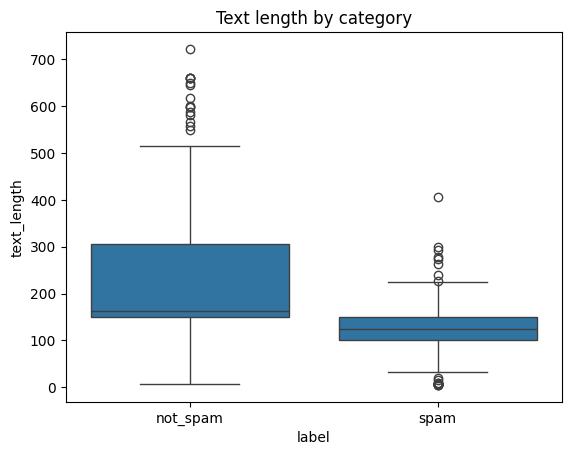

In [30]:
sns.boxplot(df, x='label', y='text_length')
plt.title("Text length by category")
plt.show()

# Data Preparation

In [31]:
%pip install sklearn
%pip install scipy
%pip install imblearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [33]:
X = df['text']
y = df['label']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Train size: 1504, Test size: 377
label
not_spam    0.560505
spam        0.439495
Name: proportion, dtype: float64
label
not_spam    0.559682
spam        0.440318
Name: proportion, dtype: float64


In [35]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=2,             # ignore terms that appear in only 1 doc
    stop_words=None        # careful: English stopword lists won't cover Tagalog, so leave None or build custom list
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [36]:
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Modeling

In [37]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix

In [39]:
LR = LogisticRegression()
SVM = LinearSVC()
DT = DecisionTreeClassifier()
NB = MultinomialNB()
XGB = XGBClassifier()

models = {
    'SVM': {
        'model': SVM,
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'loss': ['hinge', 'squared_hinge']
        }
    },
    'LR': {
        'model': LR,
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear']
        }
    },
    'XGB': {
        'model': XGB,
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2, 1.0]
        }
    },
    'DT' : {
        'model' : DT,
        'params' : {
            'criterion': ['gini', 'entropy', 'log_loss'],
            'splitter': ['best', 'random'],
            'max_depth': [None, 3, 5, 7, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [None, 'sqrt', 'log2']
        }
    },
    'NB' : {
        'model' : NB,
        'params' : {
            'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
            'force_alpha': [True, False],
            'fit_prior': [True, False]
        }
    }
}

In [40]:
resultGSCV = {}

for name, mp in models.items():
    grid = GridSearchCV(
        estimator=mp['model'],
        param_grid=mp['params'],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    grid.fit(X_train_tfidf, y_train_encoded)
    resultGSCV[name] = {
            'best_score': grid.best_score_,
            'best_params': grid.best_params_,
            'best_estimator': grid.best_estimator_
    }
    print(f"{name}: best score={grid.best_score_:.4f}, best params={grid.best_params_}")

SVM: best score=0.9801, best params={'C': 1, 'loss': 'hinge'}
LR: best score=0.9787, best params={'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
XGB: best score=0.9608, best params={'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
DT: best score=0.9408, best params={'criterion': 'log_loss', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'splitter': 'random'}
NB: best score=0.9794, best params={'alpha': 0.01, 'fit_prior': False, 'force_alpha': True}


## Support Machine Vector

In [41]:
SVM_model = LinearSVC(C=1, loss='hinge')

SVM_model.fit(X_train_tfidf, y_train_encoded)

LinearSVC(C=1, loss='hinge')

In [42]:
svmPred = SVM_model.predict(X_test_tfidf)

print(classification_report(y_test_encoded, svmPred, digits=4))

              precision    recall  f1-score   support

           0     0.9810    0.9810    0.9810       211
           1     0.9759    0.9759    0.9759       166

    accuracy                         0.9788       377
   macro avg     0.9785    0.9785    0.9785       377
weighted avg     0.9788    0.9788    0.9788       377



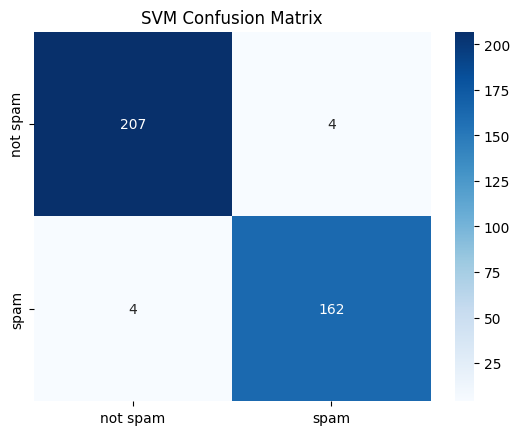

In [43]:
cm_svm = confusion_matrix(y_test_encoded, svmPred)

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['not spam', 'spam'],
            yticklabels=['not spam', 'spam'])
plt.title('SVM Confusion Matrix')
plt.show()

## Naive Bayes

In [44]:
NB_model = MultinomialNB(alpha=0.01, fit_prior=False, force_alpha=True)

NB_model.fit(X_train_tfidf, y_train_encoded)

MultinomialNB(alpha=0.01, fit_prior=False)

In [45]:
NB_pred = NB_model.predict(X_test_tfidf)

print(classification_report(y_test_encoded, NB_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9811    0.9858    0.9835       211
           1     0.9818    0.9759    0.9789       166

    accuracy                         0.9814       377
   macro avg     0.9815    0.9808    0.9812       377
weighted avg     0.9814    0.9814    0.9814       377



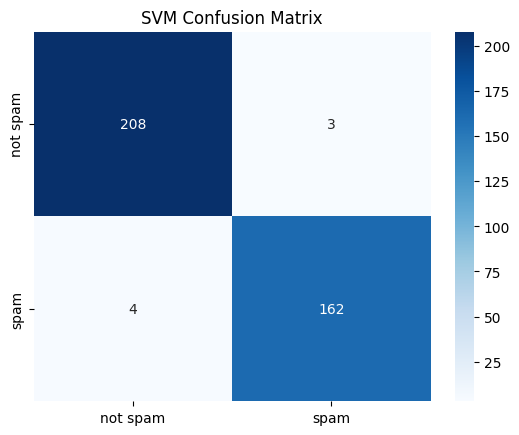

In [46]:
cm_nb = confusion_matrix(y_test_encoded, NB_pred)

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['not spam', 'spam'],
            yticklabels=['not spam', 'spam'])
plt.title('SVM Confusion Matrix')
plt.show()

## Logistic Regression

In [47]:
LR_model = LogisticRegression(penalty='l2', C=10, solver='liblinear')

LR_model.fit(X_train_tfidf, y_train_encoded)

LogisticRegression(C=10, solver='liblinear')

In [48]:
lrPred = LR_model.predict(X_test_tfidf)

print(classification_report(y_test_encoded, lrPred, digits=4))

              precision    recall  f1-score   support

           0     0.9810    0.9810    0.9810       211
           1     0.9759    0.9759    0.9759       166

    accuracy                         0.9788       377
   macro avg     0.9785    0.9785    0.9785       377
weighted avg     0.9788    0.9788    0.9788       377



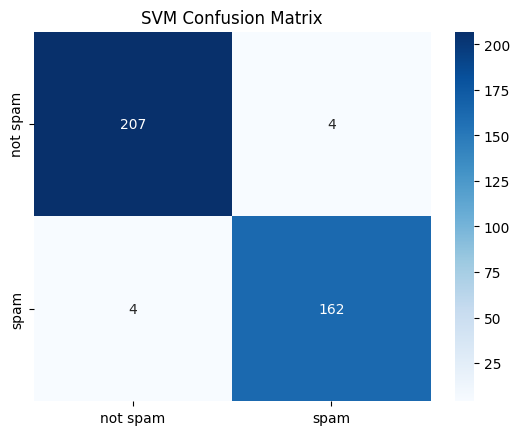

In [49]:
cm_lr = confusion_matrix(y_test_encoded, lrPred)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['not spam', 'spam'],
            yticklabels=['not spam', 'spam'])
plt.title('SVM Confusion Matrix')
plt.show()

# Cross Val